# 02 — Missing values

**Child Mind Institute — Problematic Internet Use**

Цель ноутбука — понять не только количество пропусков, но и их структуру.

Разбираем:

- missingness по отдельным признакам;
- missingness по участникам;
- различия между участниками с известным и неизвестным `sii`;
- missingness внутри классов `sii`;
- отсутствие целых инструментов / обследований;
- структурные пропуски, связанные с возрастом.



## 1. Imports and data loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

TARGET = "sii"
ID_COL = "id"
AGE_COL = "Basic_Demos-Age"


In [2]:
# Работает при запуске Jupyter как из корня проекта, так и из project/notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
DATA_DICT_PATH = DATA_DIR / "data_dictionary.csv"

for path in [TRAIN_PATH, TEST_PATH, DATA_DICT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
data_dict = pd.read_csv(DATA_DICT_PATH)

MODEL_FEATURES = [c for c in test.columns if c != ID_COL]
train_labeled = train.loc[train[TARGET].notna()].copy()
train_unlabeled = train.loc[train[TARGET].isna()].copy()

print("Train:", train.shape)
print("Test:", test.shape)
print("Labeled train:", train_labeled.shape)
print("Unlabeled train:", train_unlabeled.shape)
print(f"Missing target: {train[TARGET].isna().mean():.1%}")


Train: (3960, 82)
Test: (20, 59)
Labeled train: (2736, 82)
Unlabeled train: (1224, 82)
Missing target: 30.9%


## 2. Missing target

`train.csv` содержит строки без `sii`. Они могут быть полезны для unsupervised/statistical анализа признаков, но не входят в обычное supervised-обучение с `sii` в качестве target.

Поэтому далее важно различать:

- `train` — все участники;
- `train_labeled` — только участники с известным `sii`;
- `train_unlabeled` — участники без `sii`.


In [3]:
target_availability = pd.DataFrame({
    "group": ["sii available", "sii missing"],
    "n": [train[TARGET].notna().sum(), train[TARGET].isna().sum()],
    "fraction": [train[TARGET].notna().mean(), train[TARGET].isna().mean()],
})

display(target_availability)


,group,n,fraction
0,sii available,2736,0.690909
1,sii missing,1224,0.309091


## 3. Missingness by feature

In [4]:
feature_missingness = pd.DataFrame({
    "train_missing_n": train[MODEL_FEATURES].isna().sum(),
    "train_missing_%": train[MODEL_FEATURES].isna().mean() * 100,
    "test_missing_n": test[MODEL_FEATURES].isna().sum(),
    "test_missing_%": test[MODEL_FEATURES].isna().mean() * 100,
})

feature_missingness["train_available_n"] = (
    len(train) - feature_missingness["train_missing_n"]
)
feature_missingness["test_available_n"] = (
    len(test) - feature_missingness["test_missing_n"]
)
feature_missingness["test_minus_train_pp"] = (
    feature_missingness["test_missing_%"]
    - feature_missingness["train_missing_%"]
)

feature_missingness = feature_missingness.sort_values(
    "train_missing_%",
    ascending=False,
)

display(feature_missingness.round(2))


,train_missing_n,train_missing_%,test_missing_n,test_missing_%,train_available_n,test_available_n,test_minus_train_pp
PAQ_A-Season,3485,88.01,19,95.0,475,1,6.99
PAQ_A-PAQ_A_Total,3485,88.01,19,95.0,475,1,6.99
Fitness_Endurance-Time_Mins,3220,81.31,17,85.0,740,3,3.69
Fitness_Endurance-Time_Sec,3220,81.31,17,85.0,740,3,3.69
Fitness_Endurance-Max_Stage,3217,81.24,17,85.0,743,3,3.76
Physical-Waist_Circumference,3062,77.32,15,75.0,898,5,-2.32
FGC-FGC_GSND_Zone,2898,73.18,15,75.0,1062,5,1.82
FGC-FGC_GSD_Zone,2897,73.16,15,75.0,1063,5,1.84
FGC-FGC_GSD,2886,72.88,15,75.0,1074,5,2.12
FGC-FGC_GSND,2886,72.88,15,75.0,1074,5,2.12


### Most sparse features

В supplied `test.csv` очень мало строк, поэтому `test_missing_%` имеет высокую дискретность и не должен интерпретироваться как надёжная оценка distribution shift. Здесь test используется в основном для контроля схемы.


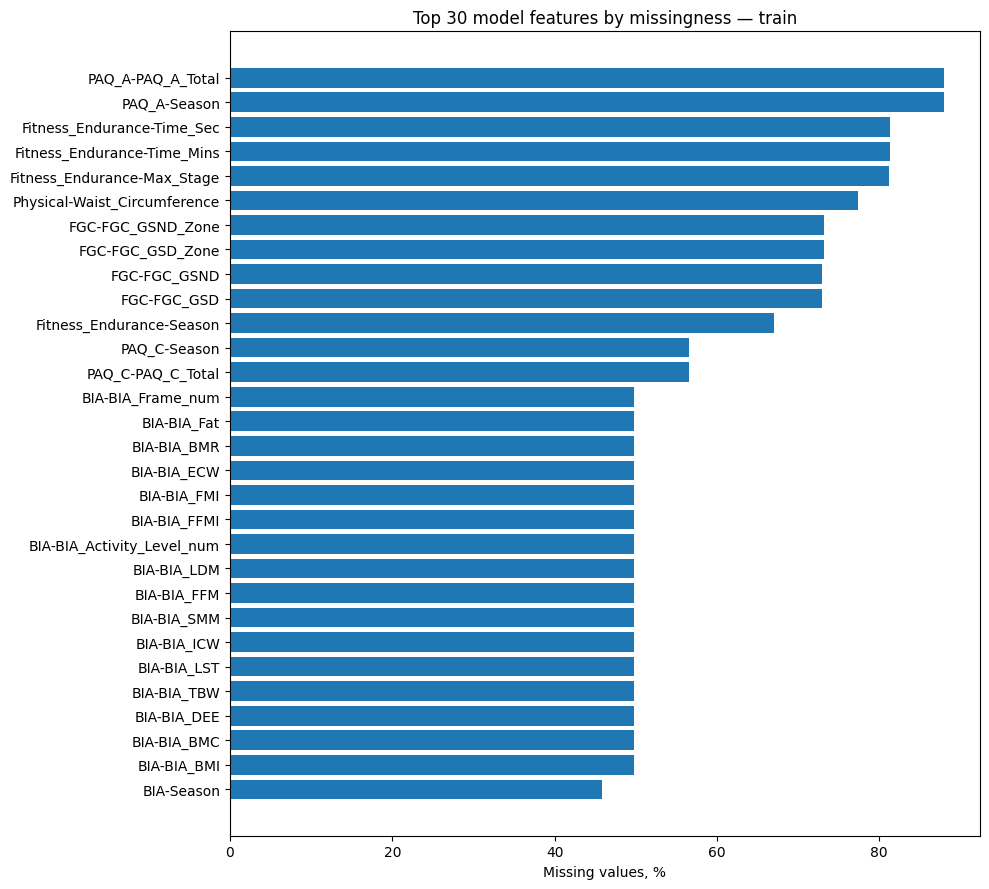

In [5]:
top_missing = feature_missingness.loc[
    feature_missingness["train_missing_%"] > 0,
    "train_missing_%",
].head(30).sort_values()

plt.figure(figsize=(10, 9))
plt.barh(top_missing.index, top_missing.values)
plt.xlabel("Missing values, %")
plt.ylabel("")
plt.title("Top 30 model features by missingness — train")
plt.tight_layout()
plt.show()


## 4. Missingness per participant

In [6]:
participant_missingness = pd.DataFrame({
    ID_COL: train[ID_COL],
    TARGET: train[TARGET],
})

participant_missingness["n_missing"] = (
    train[MODEL_FEATURES].isna().sum(axis=1)
)
participant_missingness["missing_%"] = (
    train[MODEL_FEATURES].isna().mean(axis=1) * 100
)
participant_missingness["target_available"] = train[TARGET].notna()

display(
    participant_missingness[["n_missing", "missing_%"]]
    .describe()
    .round(2)
)


,n_missing,missing_%
count,3960.00,3960.00
mean,26.13,45.04
std,17.25,29.75
min,3.00,5.17
25%,9.00,15.52
50%,24.00,41.38
75%,41.00,70.69
max,55.00,94.83


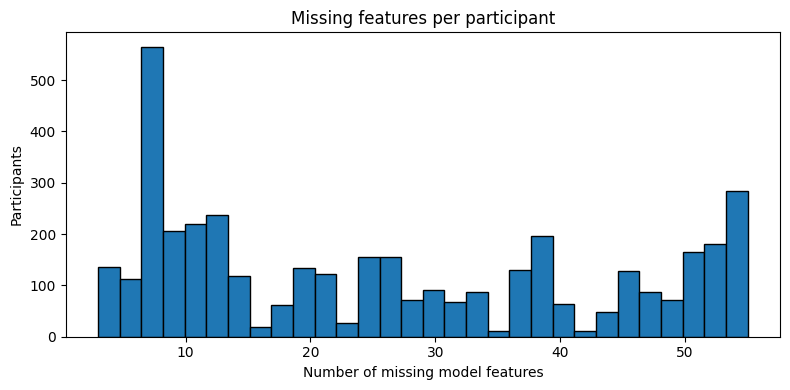

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(
    participant_missingness["n_missing"],
    bins=30,
    edgecolor="black",
)
plt.xlabel("Number of missing model features")
plt.ylabel("Participants")
plt.title("Missing features per participant")
plt.tight_layout()
plt.show()


## 5. Is missingness related to target availability?

Это критически важная проверка. Если строки без `sii` одновременно имеют существенно меньше доступных признаков, то `sii` missingness не является нейтральным относительно качества обследования.


In [8]:
missingness_by_target_availability = (
    participant_missingness
    .groupby("target_available")["n_missing"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={False: "sii missing", True: "sii available"})
)

display(missingness_by_target_availability.round(2))


,count,mean,median,std,min,max
target_available,,,,,,
sii missing,1224,42.28,50.0,13.75,6,55
sii available,2736,18.90,13.0,13.31,3,53


C:\Users\HP\AppData\Local\Temp\ipykernel_14132\116224855.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


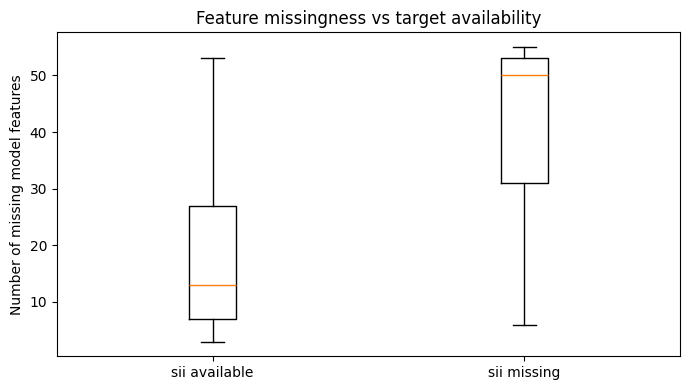

In [9]:
available = participant_missingness.loc[
    participant_missingness["target_available"], "n_missing"
]
missing = participant_missingness.loc[
    ~participant_missingness["target_available"], "n_missing"
]

plt.figure(figsize=(7, 4))
plt.boxplot(
    [available, missing],
    labels=["sii available", "sii missing"],
    showfliers=False,
)
plt.ylabel("Number of missing model features")
plt.title("Feature missingness vs target availability")
plt.tight_layout()
plt.show()


### Dataset-specific observation

Для исходного competition train эта проверка показывает сильное различие: строки без `sii` в среднем значительно более неполные, чем строки с известным target.

Это означает, что перед supervised-моделированием недостаточно просто удалить строки с `sii = NaN` и забыть о них: нужно помнить, что labeled subset является более полно обследованной частью исходной выборки.


## 6. Missingness within SII classes

In [10]:
missingness_by_sii = (
    participant_missingness
    .dropna(subset=[TARGET])
    .groupby(TARGET)["n_missing"]
    .agg(["count", "mean", "median", "std"])
)

display(missingness_by_sii.round(2))


,count,mean,median,std
sii,,,,
0.0,1594,19.00,13.0,13.17
1.0,730,18.80,12.0,13.48
2.0,378,18.81,12.0,13.64
3.0,34,17.00,9.5,12.97


C:\Users\HP\AppData\Local\Temp\ipykernel_14132\2900234269.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


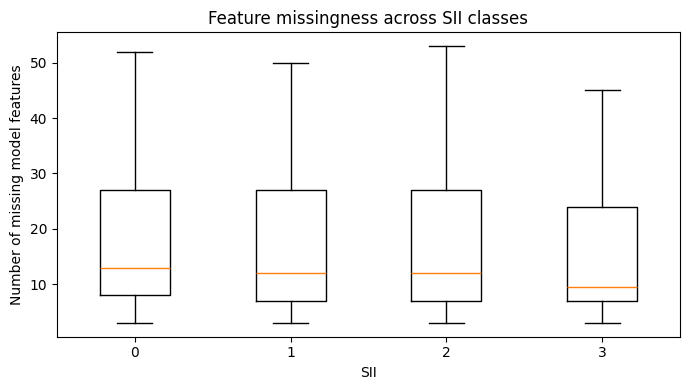

In [11]:
sii_groups = [
    participant_missingness.loc[
        participant_missingness[TARGET] == cls,
        "n_missing",
    ]
    for cls in sorted(train_labeled[TARGET].unique())
]

sii_labels = [
    str(int(cls))
    for cls in sorted(train_labeled[TARGET].unique())
]

plt.figure(figsize=(7, 4))
plt.boxplot(
    sii_groups,
    labels=sii_labels,
    showfliers=False,
)
plt.xlabel("SII")
plt.ylabel("Number of missing model features")
plt.title("Feature missingness across SII classes")
plt.tight_layout()
plt.show()


## 7. Missingness by instrument

Отдельные колонки относятся к одному и тому же обследованию. Поэтому полезнее дополнительно смотреть missingness на уровне **инструмента**, а не только отдельных признаков.

Для каждого инструмента считаем:

- среднюю долю NaN среди его model features;
- долю участников, у которых есть хотя бы одно значение;
- долю участников, у которых заполнены все признаки этого инструмента.


In [12]:
field_to_instrument = dict(
    zip(data_dict["Field"], data_dict["Instrument"])
)

instrument_rows = []

for instrument in data_dict["Instrument"].dropna().unique():
    cols = [
        c for c in MODEL_FEATURES
        if field_to_instrument.get(c) == instrument
    ]

    if not cols:
        continue

    instrument_rows.append({
        "instrument": instrument,
        "n_features": len(cols),
        "mean_missing_%": (
            train[cols].isna().mean().mean() * 100
        ),
        "participants_with_any_data_%": (
            train[cols].notna().any(axis=1).mean() * 100
        ),
        "participants_with_complete_data_%": (
            train[cols].notna().all(axis=1).mean() * 100
        ),
    })

instrument_missingness = (
    pd.DataFrame(instrument_rows)
    .sort_values("mean_missing_%", ascending=False)
    .reset_index(drop=True)
)

display(instrument_missingness.round(2))


,instrument,n_features,mean_missing_%,participants_with_any_data_%,participants_with_complete_data_%
0,Physical Activity Questionnaire (Adolescents),2,88.01,11.99,11.99
1,FitnessGram Vitals and Treadmill,4,77.71,33.03,18.66
2,Physical Activity Questionnaire (Children),2,56.54,43.46,43.46
3,Bio-electric Impedance Analysis,17,49.49,54.17,50.28
4,FitnessGram Child,15,48.55,84.49,25.98
5,Children's Global Assessment Scale,2,37.17,64.52,61.14
6,Sleep Disturbance Scale,3,34.07,66.11,65.81
7,Physical Measures,8,29.90,83.59,21.77
8,Internet Use,2,13.62,89.39,83.36
9,Demographics,3,0.00,100.00,100.00


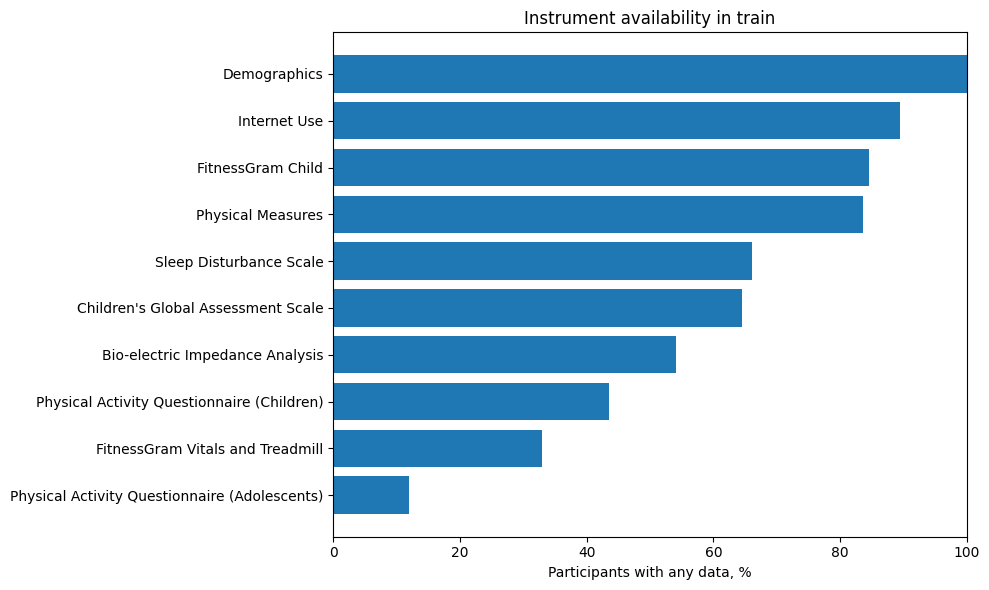

In [13]:
plot_data = (
    instrument_missingness
    .set_index("instrument")["participants_with_any_data_%"]
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(plot_data.index, plot_data.values)
plt.xlabel("Participants with any data, %")
plt.ylabel("")
plt.title("Instrument availability in train")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## 8. Structural missingness by age

Высокий процент NaN не обязательно означает плохое качество данных.

Особенно показательные признаки:

- `PAQ_C-PAQ_C_Total` — questionnaire for children;
- `PAQ_A-PAQ_A_Total` — questionnaire for adolescents;
- `Fitness_Endurance-Max_Stage` — endurance assessment.

Если availability резко меняется с возрастом, такой missingness следует рассматривать как **структурный**.


In [14]:
structural_cols = [
    "PAQ_C-PAQ_C_Total",
    "PAQ_A-PAQ_A_Total",
    "Fitness_Endurance-Max_Stage",
]
structural_cols = [
    c for c in structural_cols
    if c in train.columns
]

availability_by_age = pd.DataFrame({
    col: train.groupby(AGE_COL)[col].apply(
        lambda x: x.notna().mean()
    )
    for col in structural_cols
})

display(availability_by_age.round(3))


,PAQ_C-PAQ_C_Total,PAQ_A-PAQ_A_Total,Fitness_Endurance-Max_Stage
Basic_Demos-Age,,,
5,0.000,0.000,0.000
6,0.000,0.000,0.209
7,0.009,0.000,0.296
8,0.447,0.000,0.273
9,0.829,0.000,0.317
10,0.836,0.000,0.329
11,0.760,0.000,0.260
12,0.814,0.000,0.103
13,0.788,0.008,0.000


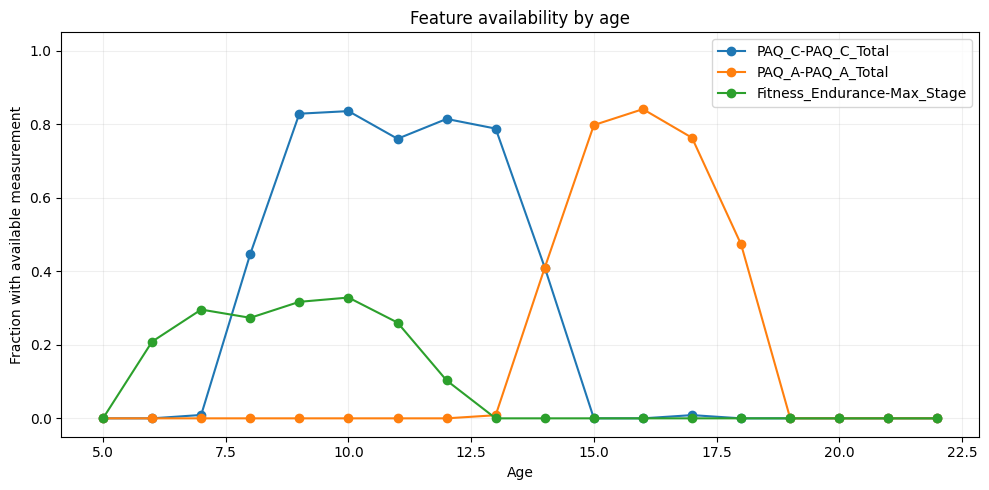

In [15]:
plt.figure(figsize=(10, 5))

for col in availability_by_age.columns:
    plt.plot(
        availability_by_age.index,
        availability_by_age[col],
        marker="o",
        label=col,
    )

plt.xlabel("Age")
plt.ylabel("Fraction with available measurement")
plt.title("Feature availability by age")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 9. Target availability by age

Проверяем также, одинаково ли часто доступен `sii` в разных возрастах. Это важно, потому что supervised subset формируется неслучайным удалением строк.


In [16]:
target_availability_by_age = (
    train
    .groupby(AGE_COL)[TARGET]
    .apply(lambda x: x.notna().mean())
    .rename("sii_available_fraction")
    .to_frame()
)

target_availability_by_age["n_participants"] = (
    train.groupby(AGE_COL).size()
)

display(target_availability_by_age.round(3))


,sii_available_fraction,n_participants
Basic_Demos-Age,,
5,0.714,112
6,0.734,369
7,0.706,436
8,0.696,490
9,0.732,467
10,0.726,420
11,0.641,334
12,0.718,291
13,0.657,236


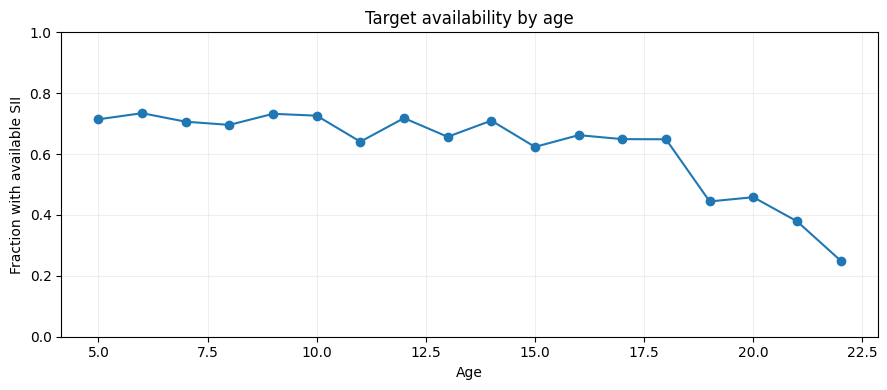

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(
    target_availability_by_age.index,
    target_availability_by_age["sii_available_fraction"],
    marker="o",
)
plt.xlabel("Age")
plt.ylabel("Fraction with available SII")
plt.title("Target availability by age")
plt.ylim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 10. Compact summary tables

Эти таблицы удобно использовать позже при выборе preprocessing strategy.


In [18]:
high_missing_features = feature_missingness.loc[
    feature_missingness["train_missing_%"] >= 50
].copy()

print(
    f"Features with >=50% missing values: "
    f"{len(high_missing_features)} / {len(MODEL_FEATURES)}"
)
display(high_missing_features.round(2))


Features with >=50% missing values: 13 / 58


,train_missing_n,train_missing_%,test_missing_n,test_missing_%,train_available_n,test_available_n,test_minus_train_pp
PAQ_A-Season,3485,88.01,19,95.0,475,1,6.99
PAQ_A-PAQ_A_Total,3485,88.01,19,95.0,475,1,6.99
Fitness_Endurance-Time_Mins,3220,81.31,17,85.0,740,3,3.69
Fitness_Endurance-Time_Sec,3220,81.31,17,85.0,740,3,3.69
Fitness_Endurance-Max_Stage,3217,81.24,17,85.0,743,3,3.76
Physical-Waist_Circumference,3062,77.32,15,75.0,898,5,-2.32
FGC-FGC_GSND_Zone,2898,73.18,15,75.0,1062,5,1.82
FGC-FGC_GSD_Zone,2897,73.16,15,75.0,1063,5,1.84
FGC-FGC_GSD,2886,72.88,15,75.0,1074,5,2.12
FGC-FGC_GSND,2886,72.88,15,75.0,1074,5,2.12


In [19]:
availability_bins = pd.cut(
    feature_missingness["train_missing_%"],
    bins=[-0.01, 10, 25, 50, 75, 100],
    labels=[
        "0–10%",
        "10–25%",
        "25–50%",
        "50–75%",
        "75–100%",
    ],
)

missingness_bins = (
    availability_bins
    .value_counts()
    .sort_index()
    .rename("n_features")
    .to_frame()
)

display(missingness_bins)


,n_features
train_missing_%,
0–10%,3
10–25%,7
25–50%,35
50–75%,7
75–100%,6


## 11. Main findings to carry forward


1. **Target missingness нельзя смешивать с feature missingness.** Строки без `sii` не подходят для обычного supervised training.
2. **Labeled и unlabeled subsets отличаются по полноте обследования.** Это потенциальный selection effect.
3. **Missingness имеет блочную структуру:** часто отсутствует не отдельная колонка, а значительная часть одного инструмента.
4. **PAQ missingness структурно зависит от возраста.** Простая глобальная median imputation не отражает причину таких NaN.
5. При preprocessing стоит рассмотреть:
   - missing indicators;
   - imputation внутри логически однородных feature groups;
   - модели, естественно работающие с NaN;
   - явный учёт возраста для age-dependent measurements.
6. Маленький supplied `test.csv` не позволяет надёжно оценивать train/test missingness shift.

